In [31]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from pathlib import Path
import matplotlib
from matplotlib import dates as mdates

matplotlib.rcParams["font.size"] = 30
matplotlib.rcParams["lines.linewidth"] = 3
matplotlib.rcParams["mathtext.default"] = 'regular'
matplotlib.rcParams['lines.markersize'] = 3


colourCycle = ['#377eb8', '#ff7f00', '#4daf4a',
              '#f781bf', '#a65628', '#984ea3',
              '#999999', "#e70004", "#8b8b02"]

anticolourcycle = ['#B250B5','#087E40','#59A9D7','#67B15C']


#Dictionary to label all the channels appropriately, assign them a unique colour and marker. 
Detectors = {'': ["LSC Left",colourCycle[0],"o"],
             'Ch_5': ["LSC Right",colourCycle[1],"v"],
             'Ch_8': ["NaI 1",colourCycle[2],"^"],
             'Ch_10': ["NaI 2",colourCycle[3],"<"],
             'Ch_12': ["NaI 3",colourCycle[4],"P"],
             'Ch_14': ["NaI 4",colourCycle[5],"s"]
             }

SampleDict = {
    "Plastic": [colourCycle[0],"o","Plastic Scintillator"],
    "LED": [colourCycle[7],"d", "LED"],
    "UnBubbled KBNL": [colourCycle[5],"*", "UnBubbled K-WBLS"],
    "Bubbled KBNL": [colourCycle[1], "^","Bubbled K-WBLS"],
    "Bubbled KUGLLT": [colourCycle[2],"s", "Bubbled K-UGLLT"],
    "LSC Left": [colourCycle[3], "<", "Annulus K-WBLS Left"],
    "LSC Right": [colourCycle[4], ">", "Annulus K-WBLS Right"]
}

K40Detectors = {'Ch_8': ["NaI 1",anticolourcycle[0],">"],
                'Ch_10': ["NaI 2",anticolourcycle[1],"^"],
                'Ch_12': ["NaI 3",anticolourcycle[2],"s"],
                'Ch_14': ["NaI 4",anticolourcycle[3],"P"],}

In [32]:
class StabilityData:
    def __init__(self,Sample):
        self.Dates = []
        self.Sample = Sample
        # self.Days = [day - self.Dates[0] for day in self.Dates]
        self.means = []
        self.Errors = []
        
        self.colour = SampleDict[Sample][0] #Sets the colour and the marker for the sample that is being plotted.
        self.marker = SampleDict[Sample][1]

    def AddEvent(self,date,mean,err):
        self.Dates.append(date)
        self.means.append(mean)
        self.Errors.append(err)
        
    def calculateDays(self):
        self.Days = [((day - min(self.Dates)).total_seconds())/(24*3600) for day in self.Dates]
        
    def calculateErrors(self):
        dayOneInd = np.argmin(self.Days)
        
        self.means = np.asarray(self.means,float)
        self.Errors = np.asarray(self.Errors,float)
        
        error = np.sqrt((self.means/self.means[dayOneInd]) * ((self.Errors/self.means) **2 + (self.Errors[dayOneInd]/self.means[dayOneInd])**2))
        self.Errors = error
        
    def plotData(self,ax):
        
        dayOneInd = np.argmin(self.Days)
        
        self.means = np.asarray(self.means,float)
        self.Errors = np.asarray(self.Errors,float)
        
        name = SampleDict[self.Sample][2]
        
        ax.scatter(self.Days,self.means/self.means[dayOneInd],color = self.colour,marker = self.marker, label = name, s = 70)
        
        ax.errorbar(self.Days,self.means/self.means[dayOneInd],yerr = self.Errors, color = self.colour, marker = self.marker,linestyle = 'None')
        

    

In [43]:
def ReadInAnnulusData(file,dayOneRemoved):
    
    currentChannel = None
    stabData = {}
    
    with open(file) as f: 
        if dayOneRemoved:
            for i in range(2):
                next(f)
        else:
            next(f) #Skips the headers
        
        for line in f:
            data = line.split('\n')[0].split(',')
            
            date = datetime.datetime(int(data[0].split('-')[0]),int(data[0].split('-')[1]),int(data[0].split('-')[2].split(" ")[0]))
            ch = int(data[1])
            sample = data[2]
            scaleFactor = float(data[5])
            scaleFactorErr = float(data[6])
            
            
            if ch == 4 or ch == 5: #We only want the LSC Stability, so this removes the NaI data that we don't want.
                if sample in stabData:
                    stabData[sample].AddEvent(date,scaleFactor,scaleFactorErr)
                else:
                    stabData[sample] = StabilityData(sample)
                    stabData[sample].AddEvent(date,scaleFactor,scaleFactorErr)
                    
    for key in stabData:
        stabData[key].calculateDays()
        stabData[key].calculateErrors()
    return stabData


def ReadInStabilityV9Data(file):
    
    samples = ["Plastic","Bubbled KBNL","Bubbled KUGLLT","LED"]
    stabV9Dict = {}
    for s in samples:
        stabV9Dict[s] = StabilityData(s)
        
    with open(file) as f:
        next(f)
        
        for line in f:
            data = line.split('\n')[0].split(',')
            ##############################
            # Indices:
            # Plastic = 1,2
            # Bubbled KBNL = 3,4
            # Bubbled KUGLLT = 5,6
            # LED = 7,8
            ##############################
            date = datetime.datetime.strptime(data[0].split('.')[0], "%Y-%m-%d %H:%M:%S")
            #datetime.datetime.strptime(data, "%Y-%m-%d %H:%M:%S")
            for i, s in enumerate(samples):
                try:
                    mean = float(data[2*i+1])
                    err = float(data[2*i+2])
                    stabV9Dict[s].AddEvent(date,mean,err)
                except: 
                    pass #catches the day where there is no fit for KUGLLT
                
                
    for key in stabV9Dict:
        stabV9Dict[key].calculateDays()
        
    return stabV9Dict


def ReadInStabilityV8Data(file):
    
    stabV8Data = {"UnBubbled KBNL": StabilityData("UnBubbled KBNL")}
    
    with open(file) as f:
        next(f)
        
        for line in f:
            data = line.split('\n')[0].split(',')
            
            date = datetime.datetime.strptime(data[0], "%Y-%m-%d %H:%M:%S")
            mean = float(data[1])
            err = 0
            for key in stabV8Data:
                stabV8Data[key].AddEvent(date,mean,err)
    for key in stabV8Data:
        stabV8Data[key].calculateDays()
        
    return stabV8Data
        

In [44]:
AnnulusDataFilePath = '/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/Results/Annulus_stability_data_average.txt'
StabilityV9FilePath = '/home/nick/PhD/KDK+/Stability_experiment_Luca/file/Stability_experiment_iteration1/figure/stability_data_1071h.csv'
StabilityV8FilePath = '/home/nick/PhD/KDK+/Stability_experiment_Luca/file/Stability_experiment_iteration1/figure/unbubbled_KBNL_reference.csv'

dayOneRemoved = False
annulusData = ReadInAnnulusData(AnnulusDataFilePath,dayOneRemoved)
stabV9Data = ReadInStabilityV9Data(StabilityV9FilePath)
stabV8Data = ReadInStabilityV8Data(StabilityV8FilePath)


print(annulusData['LSC Left'].Days)


[0.0, 1.0, 2.0, 3.0, 6.0, 7.0, 8.0, 9.0, 10.0, 13.0, 14.0, 15.0, 16.0, 17.0, 21.0, 22.0, 24.0, 27.0, 28.0, 29.0, 30.0, 31.0, 34.0, 35.0, 36.0, 37.0, 38.0, 41.0, 42.0, 43.0, 44.0, 45.0, 48.0, 49.0, 50.0, 51.0, 52.0]


52.0
[0.01034468 0.009464   0.0091472  0.00897861 0.0096417  0.0121874
 0.01154713 0.00942446 0.00994415 0.00956557 0.0093867  0.01153795
 0.00903866 0.01719896 0.01313256 0.01194711 0.01259893 0.01173269
 0.01211472 0.01380865 0.01194944 0.01124644 0.0116111  0.01244671
 0.01216736 0.01271577 0.01150338 0.01014749 0.0129153  0.01409332
 0.01246734 0.0115752  0.01201944 0.01016633 0.01350434 0.01360057
 0.01311927]
52.0
[0.00872428 0.008537   0.00866319 0.00847435 0.00777375 0.0130015
 0.01123578 0.00899734 0.00843785 0.0083637  0.00882692 0.01097048
 0.00870341 0.0064558  0.01225449 0.01198657 0.01478924 0.01090158
 0.01234254 0.01266644 0.01186657 0.01243804 0.01231379 0.01307735
 0.01301385 0.01283278 0.01357963 0.00947604 0.01261949 0.01338025
 0.01334105 0.01308536 0.01301782 0.01023078 0.01404273 0.01116408
 0.01434383]
44.166666666666664
44.166666666666664
44.166666666666664
44.166666666666664


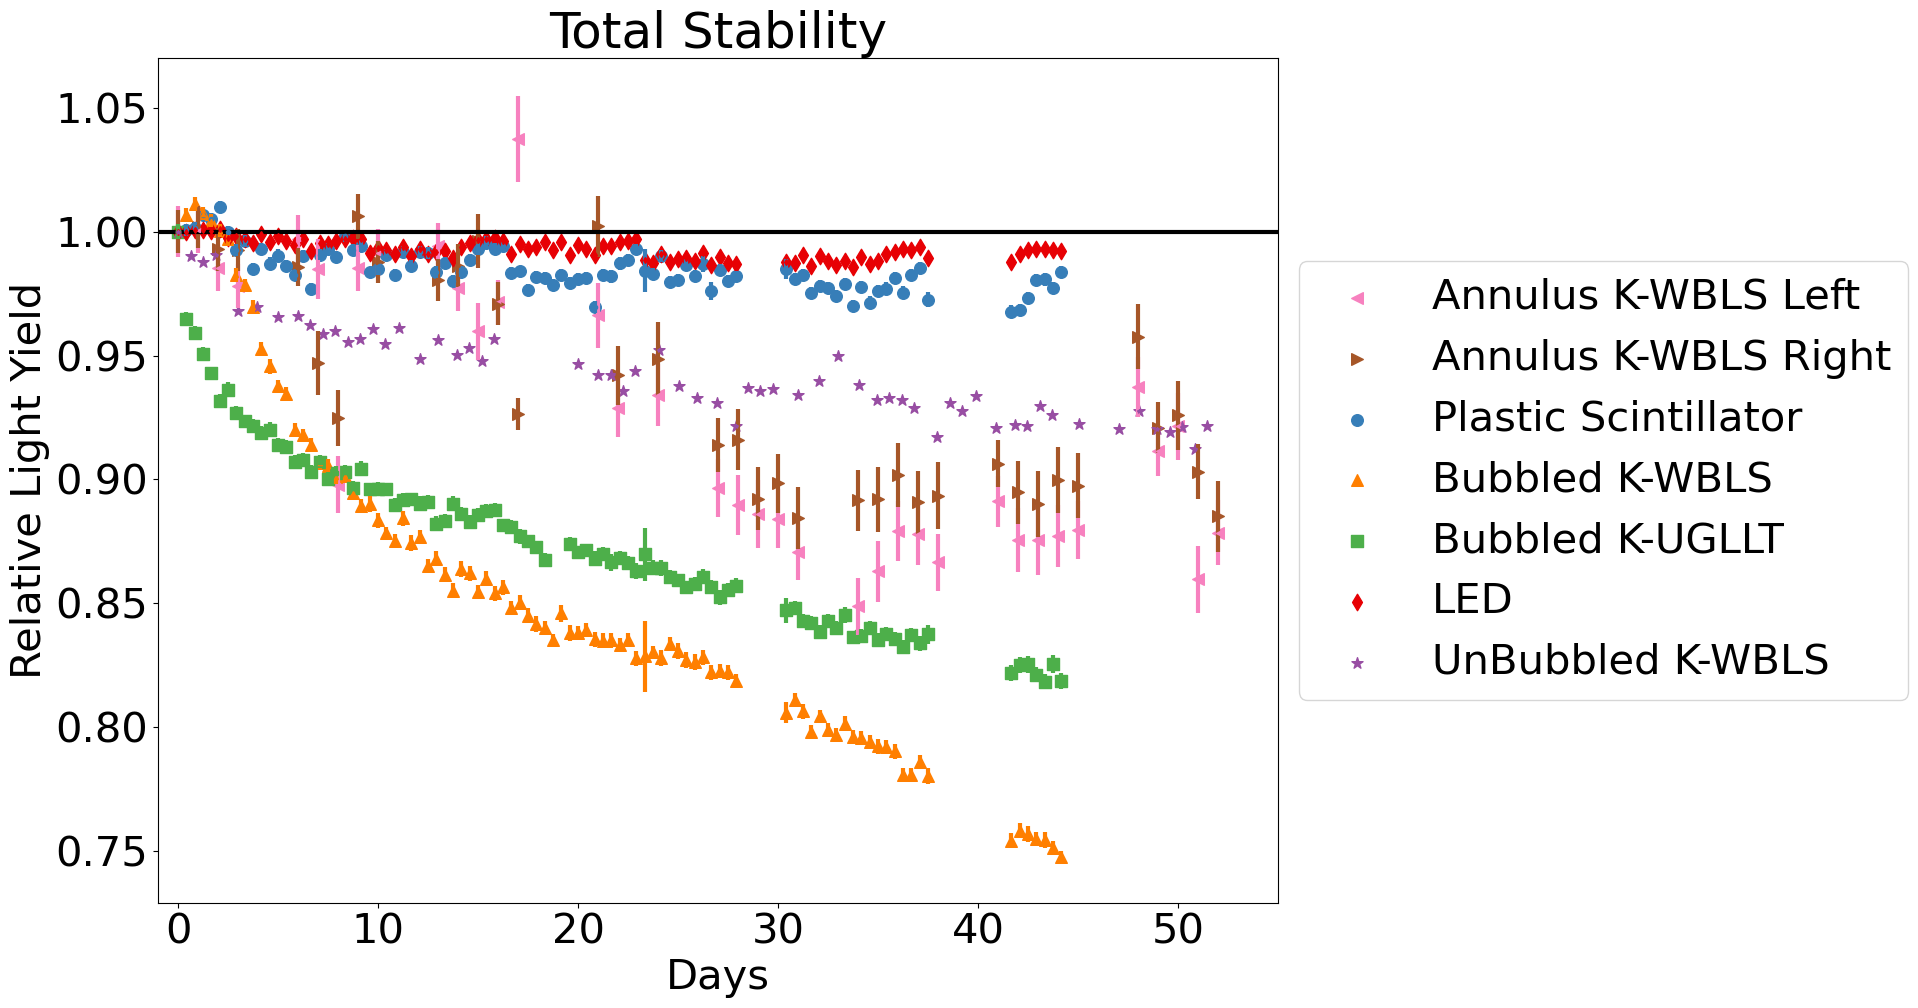

In [46]:


fig,ax = plt.subplots(1,1, figsize = (20,10))
plt.tight_layout()
# ax[0].scatter(annulusData['LSC Left'].Days, annulusData['LSC Left'].means)
# ax[1].scatter(annulusData['LSC Right'].Days, annulusData['LSC Right'].means)
# ax.scatter(annulusData['LSC Left'].Dates, annulusData['LSC Left'].means)
plt.subplots_adjust(left = 0.1,right = 0.8)
for key in annulusData:
    annulusData[key].plotData(ax)
    print(max(annulusData[key].Days))
    print(annulusData[key].Errors)
    

for key in stabV9Data:
    stabV9Data[key].plotData(ax)
    print(max(stabV9Data[key].Days))
    
for key in stabV8Data:
    stabV8Data[key].plotData(ax)

ax.axhline(1, color = 'black')
# Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax.legend(loc = 'best')
ax.set_xlabel('Days')
ax.set_ylabel('Relative Light Yield')
ax.set_xlim(-1,55)
# ax.set_ylim(0.98,1.02)

if dayOneRemoved:
    plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Total_stability_data_annulus_day_1_removed.png')
    plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Total_stability_data_annulus_day_1_removed.pdf')
    ax.set_title('Total Stability - Annulus Day 1 removed')
else:
    plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Total_stability_data.png')
    plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Total_stability_data.pdf')
    ax.set_title('Total Stability')
plt.show()